In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
from datetime import date
from concurrent.futures import ThreadPoolExecutor, as_completed

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_soil_layers,
    jablje_curve_number,
    jablje_readily_evaporable_water,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_initial_cond,
    jablje_groundwater,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")
observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [4]:
# One-at-a-time sweep: for each parameter, vary across these values (all others stay at default)
sweep_params = {
    # Biomass driver — key for biomass calibration
    "water_productivity":    [24, 28, 34, 38, 42],              # default: 33.7
    "gdd_emergence":         [20, 24, 29, 33, 38],              # default: 29
    "gdd_senescence":        [900, 980, 1072, 1150, 1230],      # default: 1072
    "gdd_maturity":          [1100, 1210, 1320, 1430, 1540],    # default: 1320
    "gdd_cycle_length":      [1100, 1210, 1320, 1430, 1540],    # default: 1320
    "gdd_flowering":         [420, 465, 510, 555, 600],         # default: 508
    "gdd_flowering_length":  [110, 130, 150, 170, 190],         # default: 150
    "max_canopy_cover":      [0.85, 0.90, 0.94, 0.96, 0.99],   # default: 0.96
    "min_rooting_depth":     [0.1, 0.2, 0.3, 0.4, 0.5],        # default: 0.30
    "max_rooting_depth":     [1.5, 1.9, 2.3, 2.5, 2.7],        # default: 2.30
    "harvest_index":         [0.45, 0.50, 0.55, 0.6],   # default: 0.58
}

total_runs = sum(len(v) for v in sweep_params.values())
print(f"{len(sweep_params)} parameters × 5 values = {total_runs} total simulations")

11 parameters × 5 values = 54 total simulations


In [5]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"sensitivity_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

In [6]:
def run_with_param(param_name, value):
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        params[param_name] = int(round(value)) if param_name in INTEGER_PARAMS else float(value)

        crop = Crop(name=f"{LOCATION} maize", description=f"{param_name}={value}", params=params)
        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )
        with contextlib.redirect_stdout(io.StringIO()):
            results = simulation.run()
        return param_name, value, results["season"]
    finally:
        dir_queue.put(working_dir)


# Submit all runs in parallel
sweep_results = {name: {} for name in sweep_params}

tasks = [
    (name, val)
    for name, values in sweep_params.items()
    for val in values
]

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(run_with_param, name, val) for name, val in tasks]
    for future in as_completed(futures):
        param_name, value, seasonal = future.result()
        sweep_results[param_name][value] = seasonal

print("Done.")

Done.


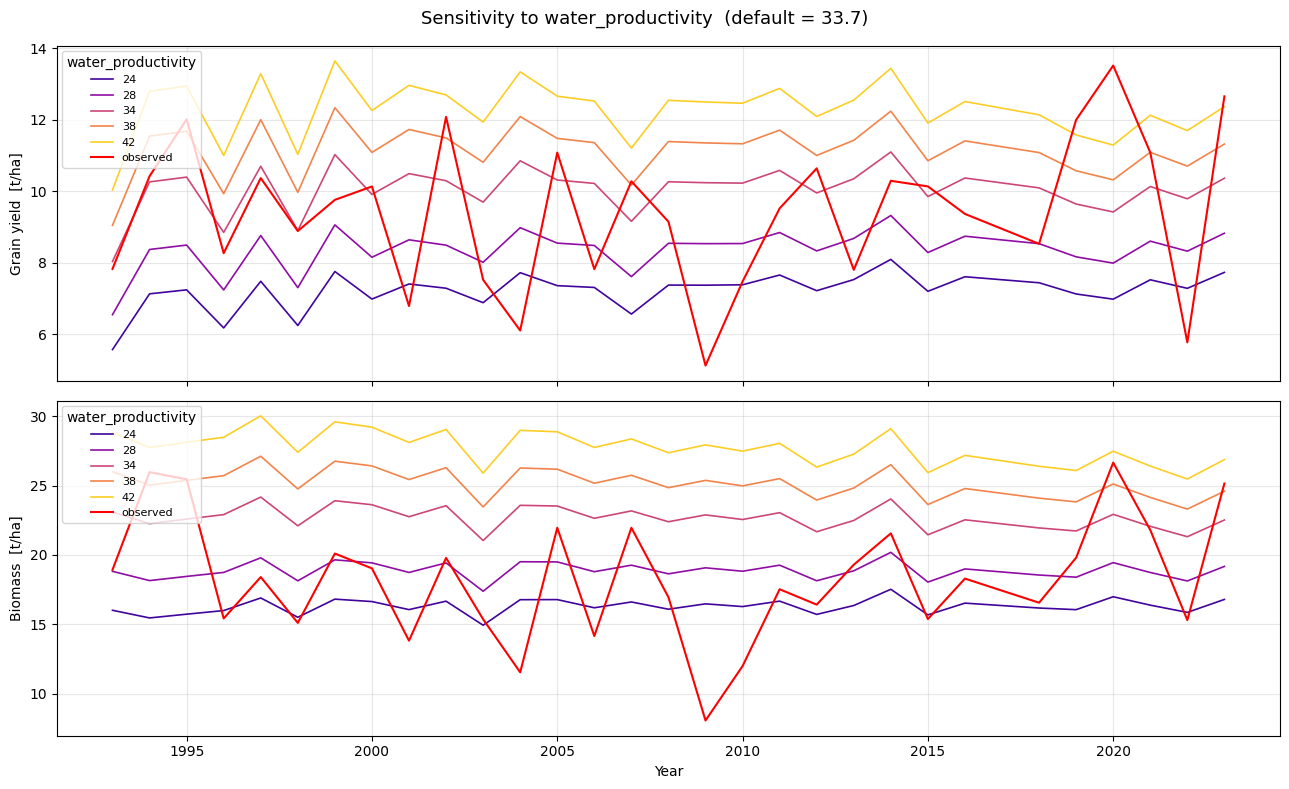

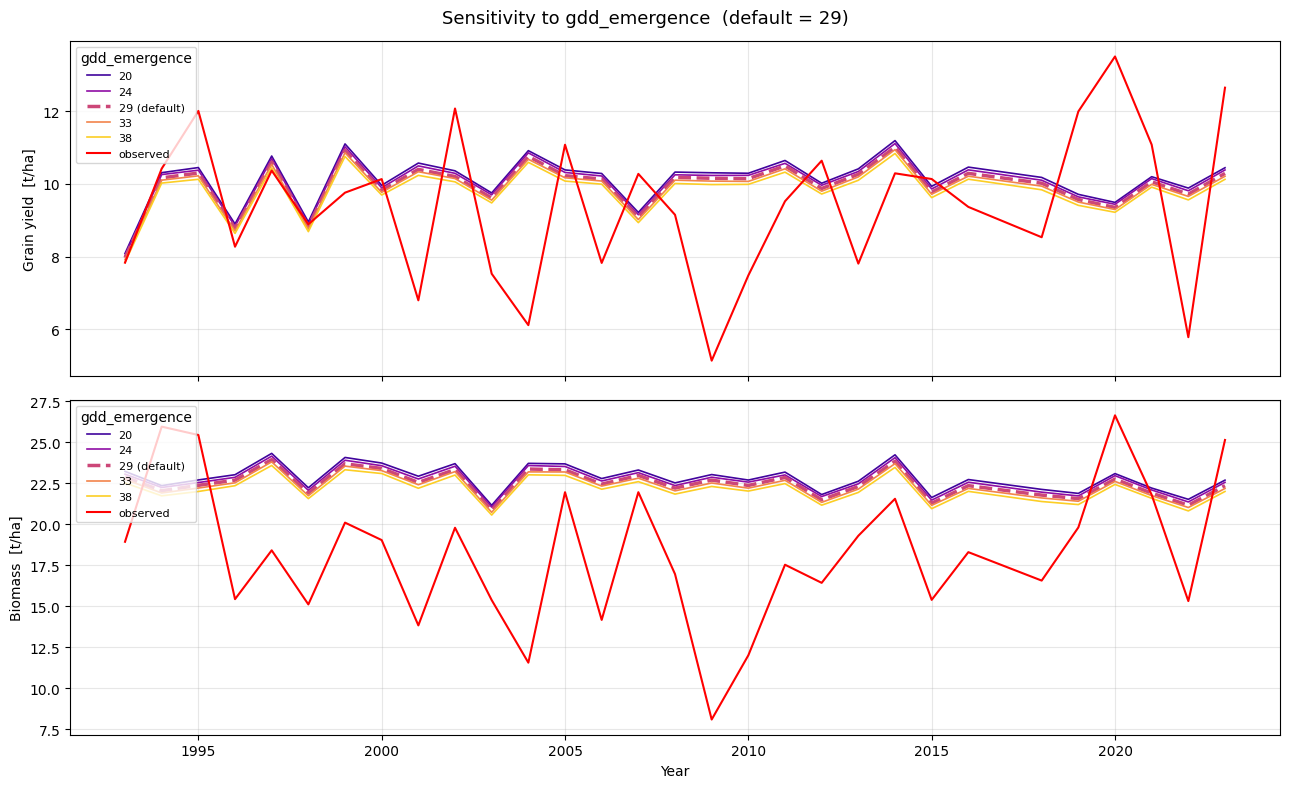

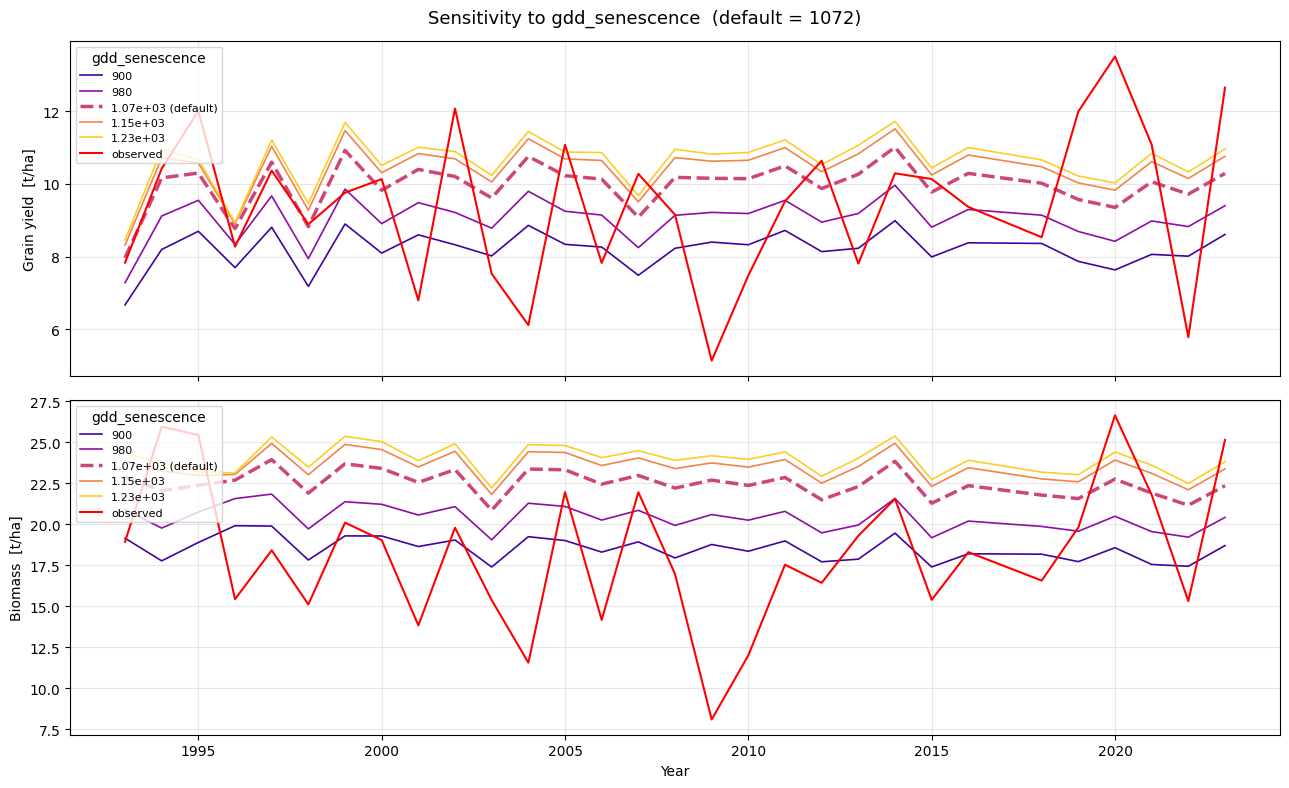

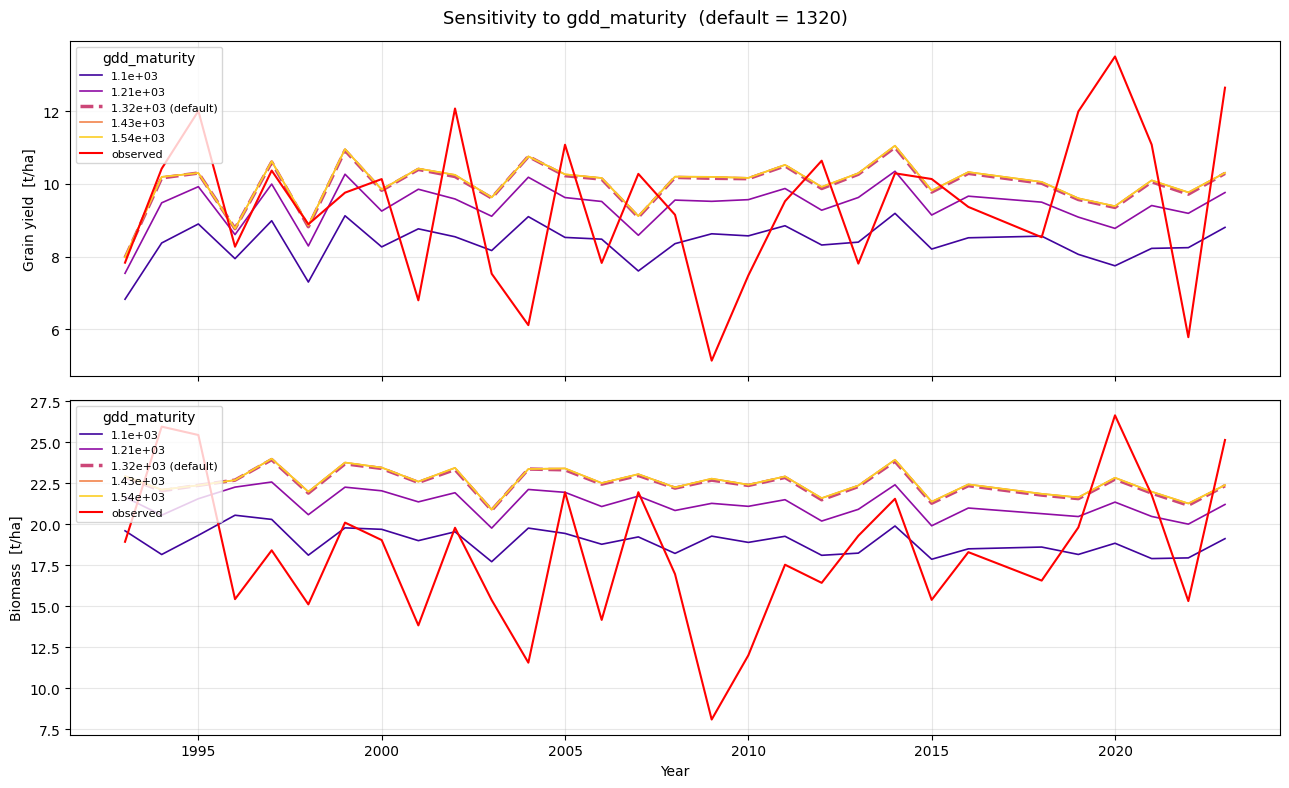

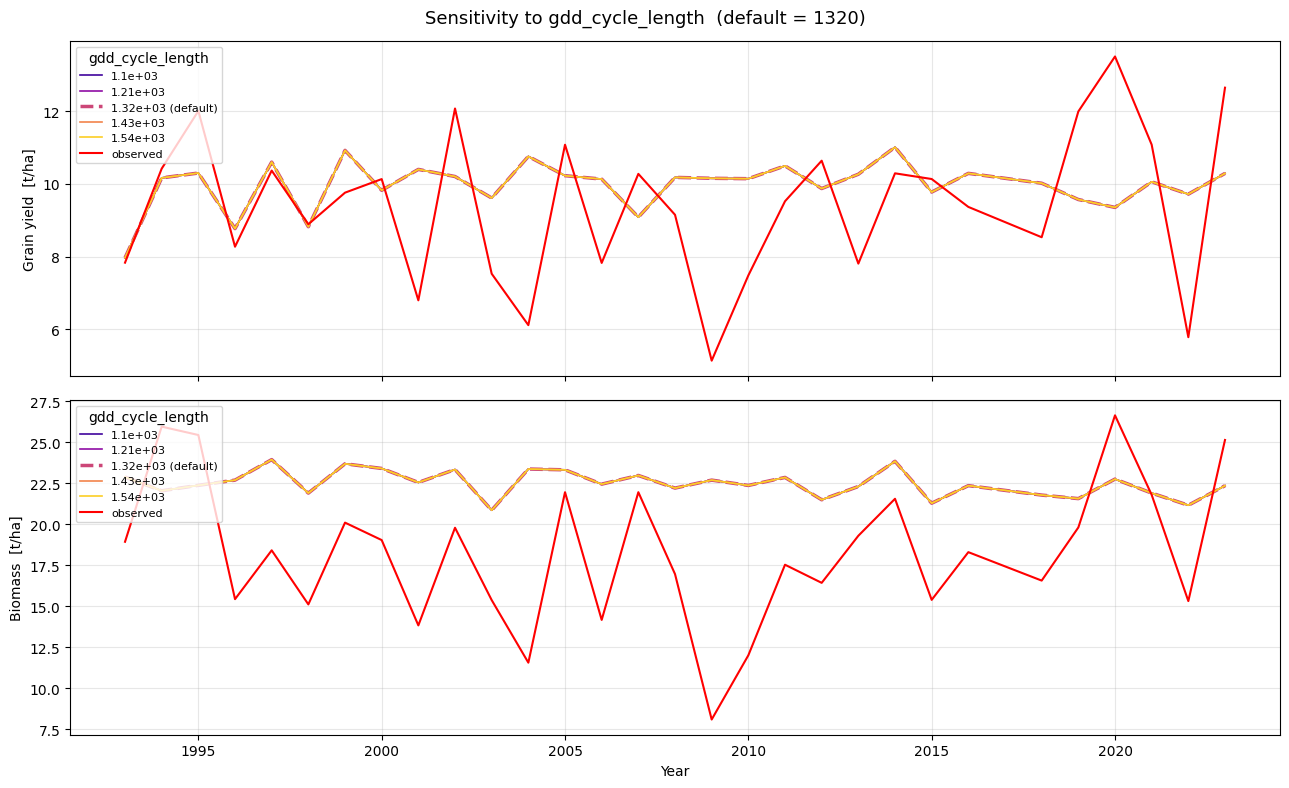

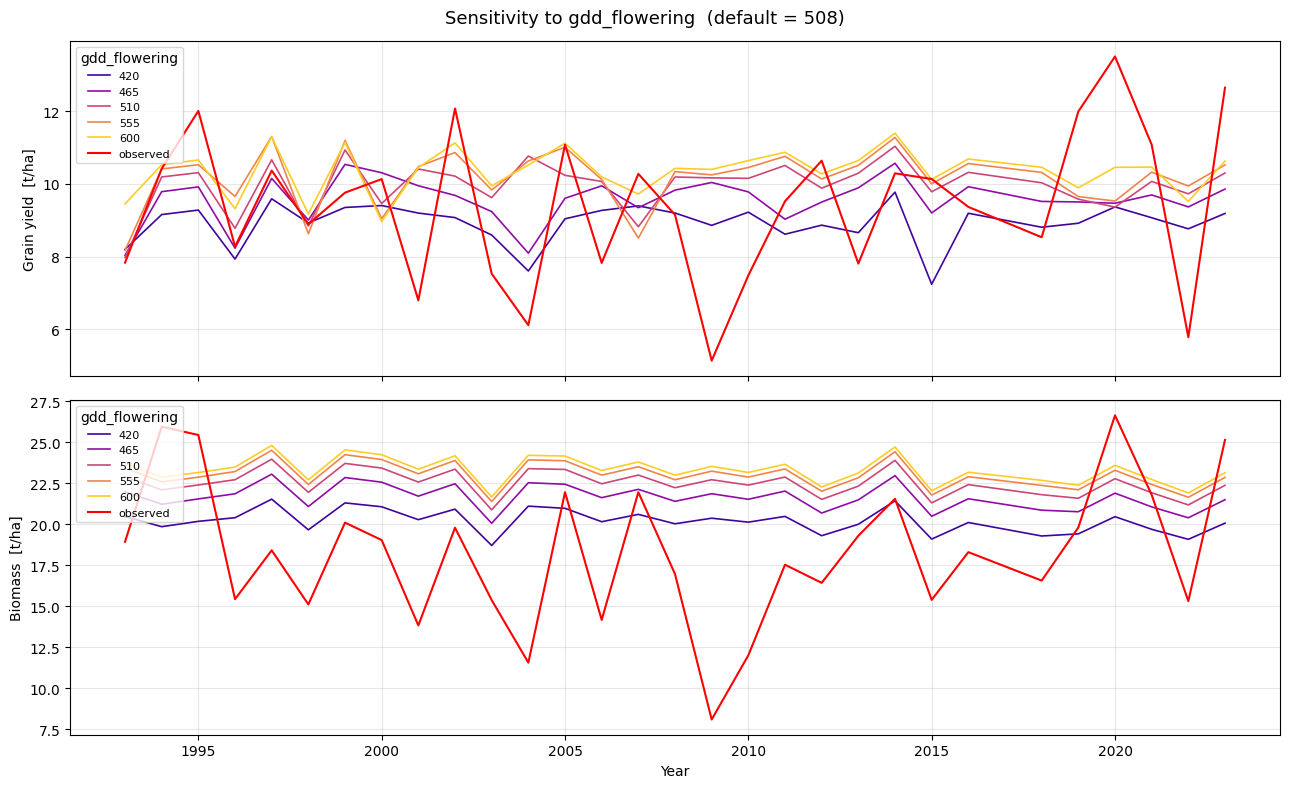

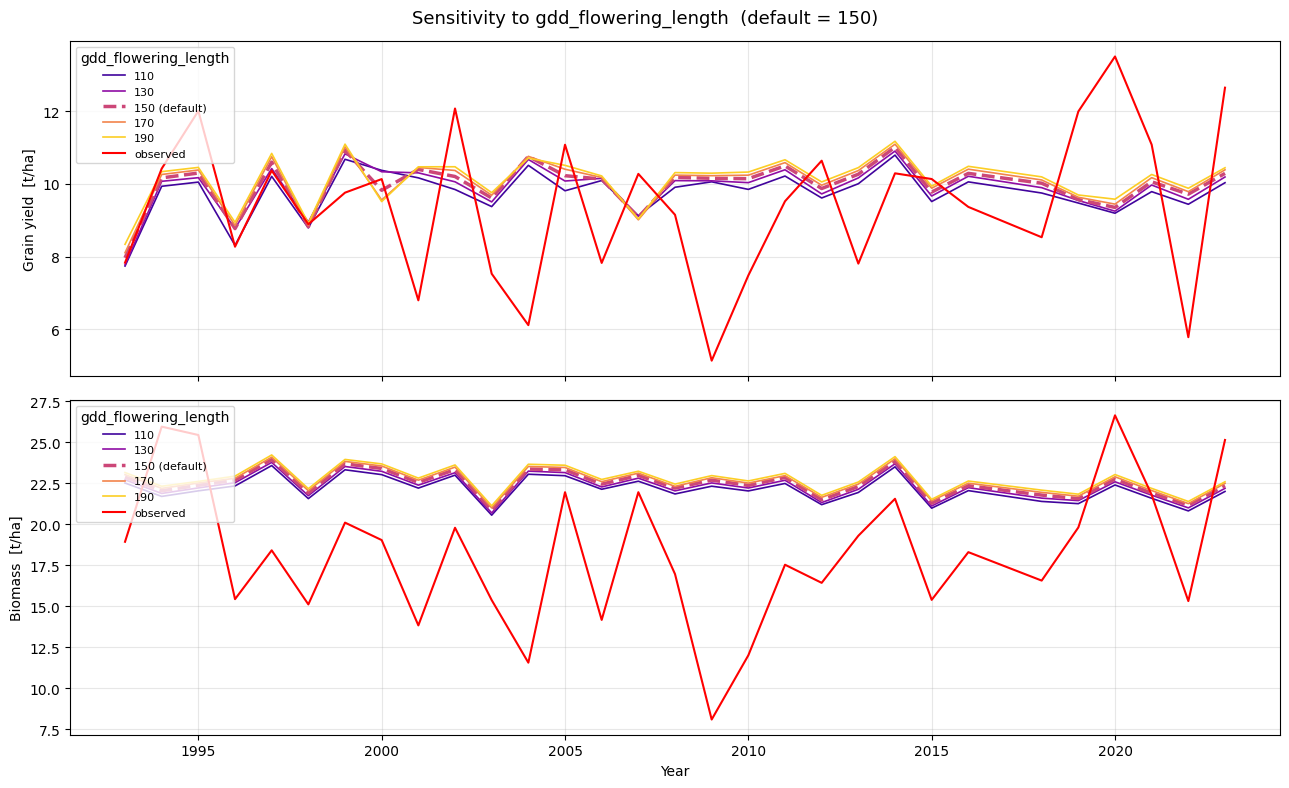

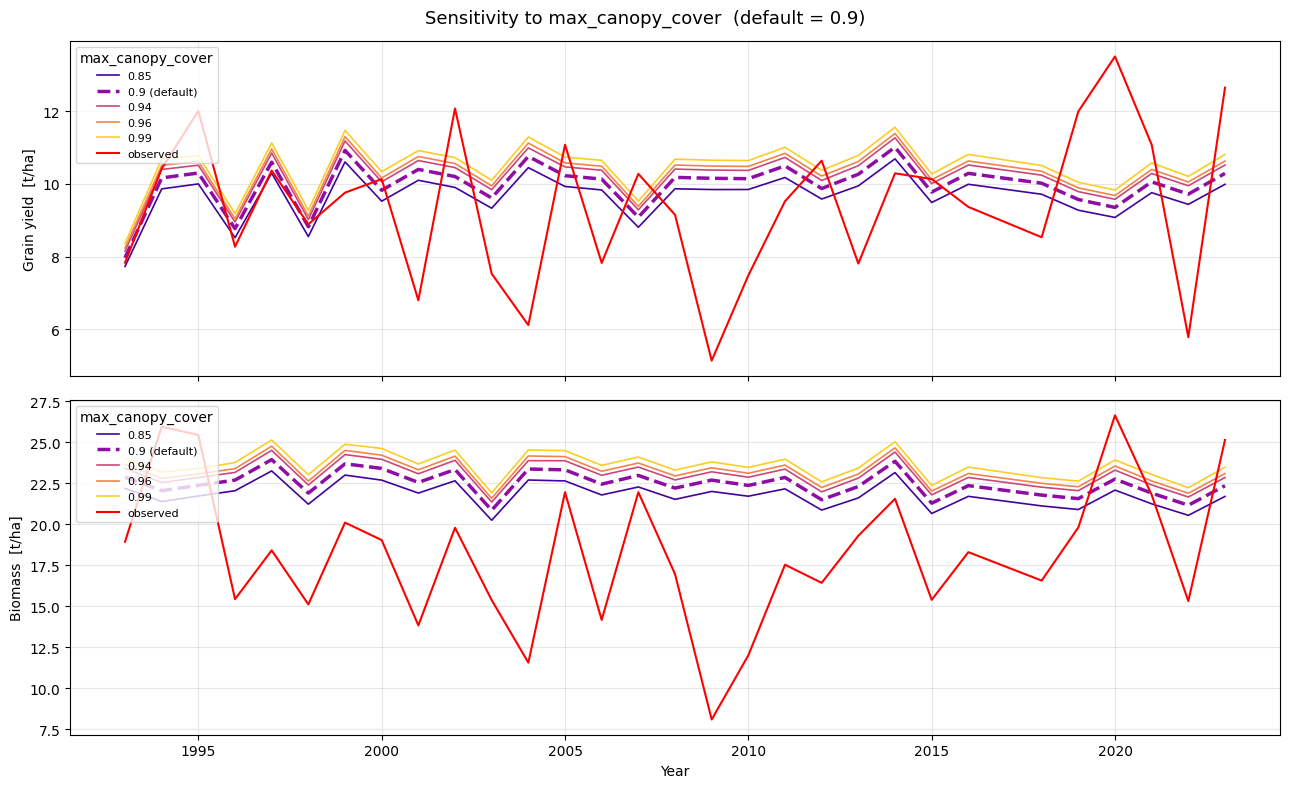

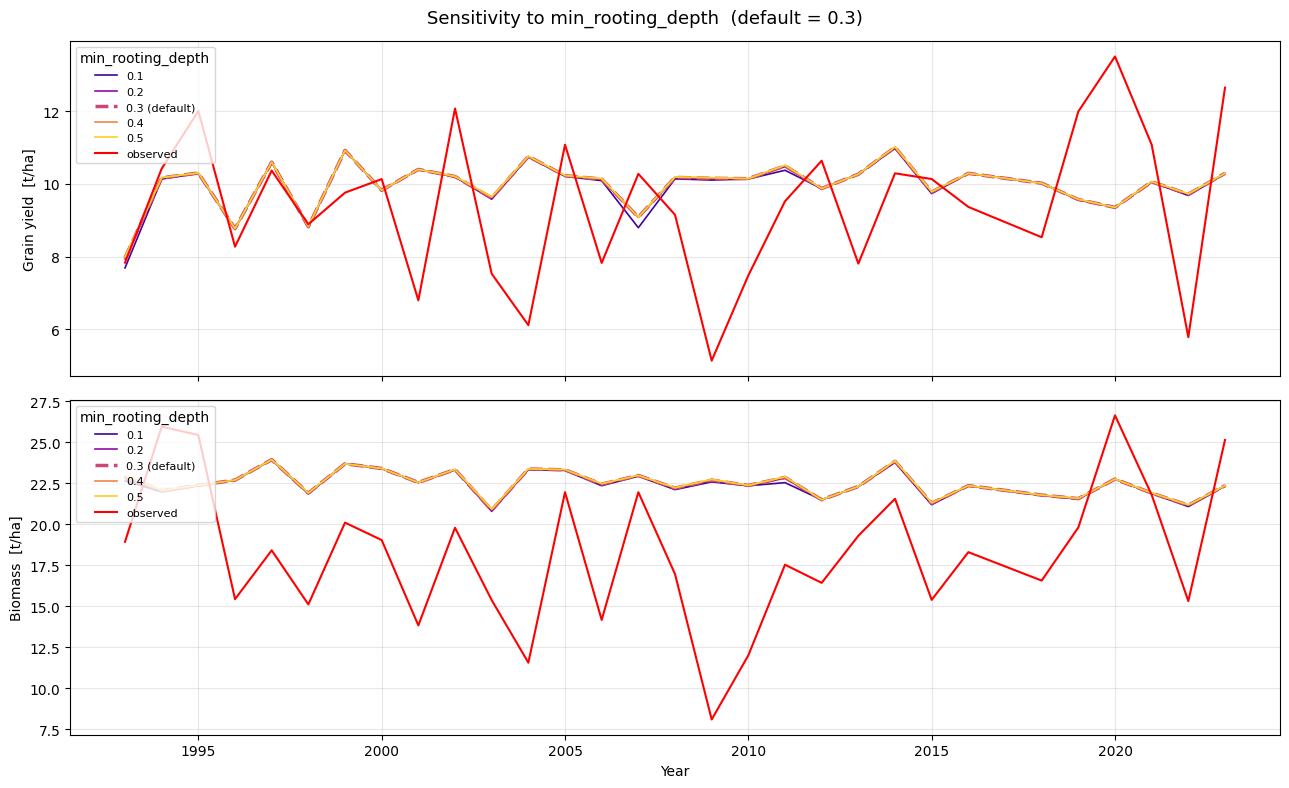

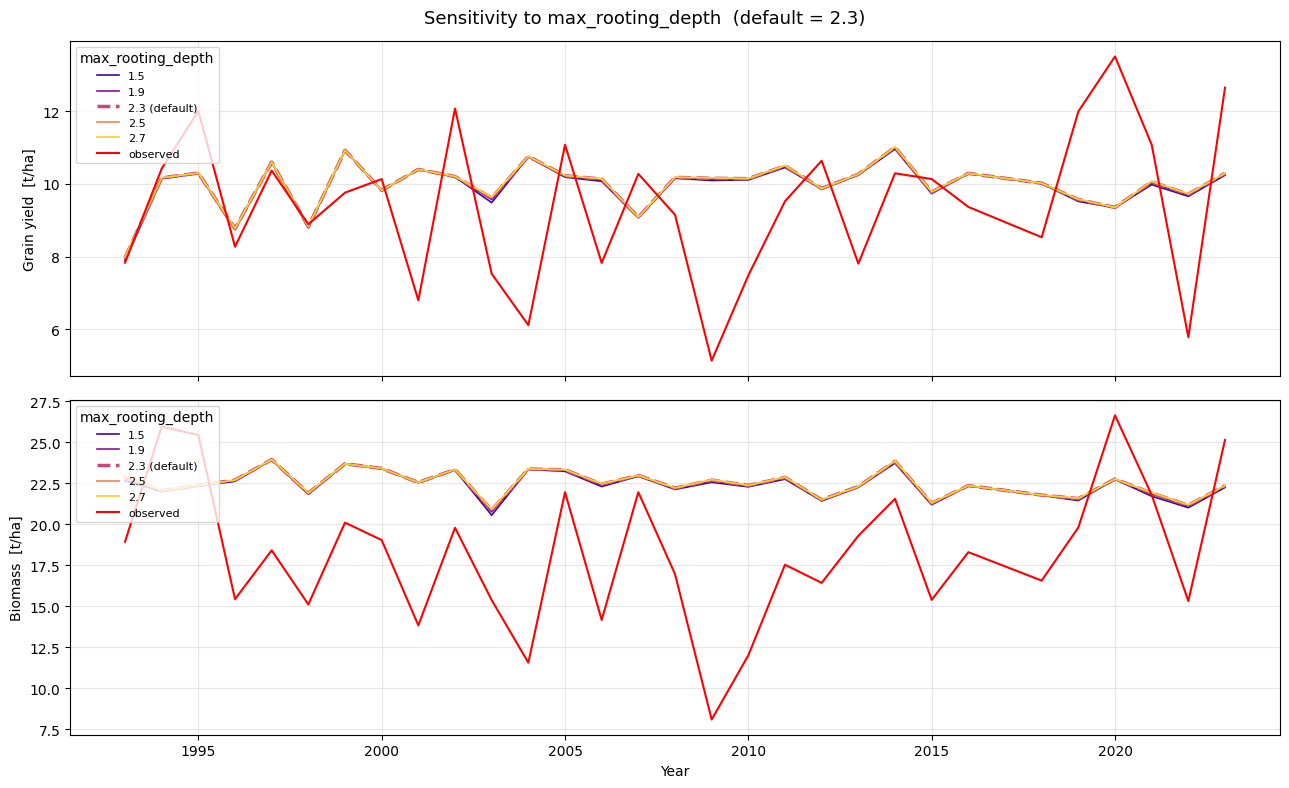

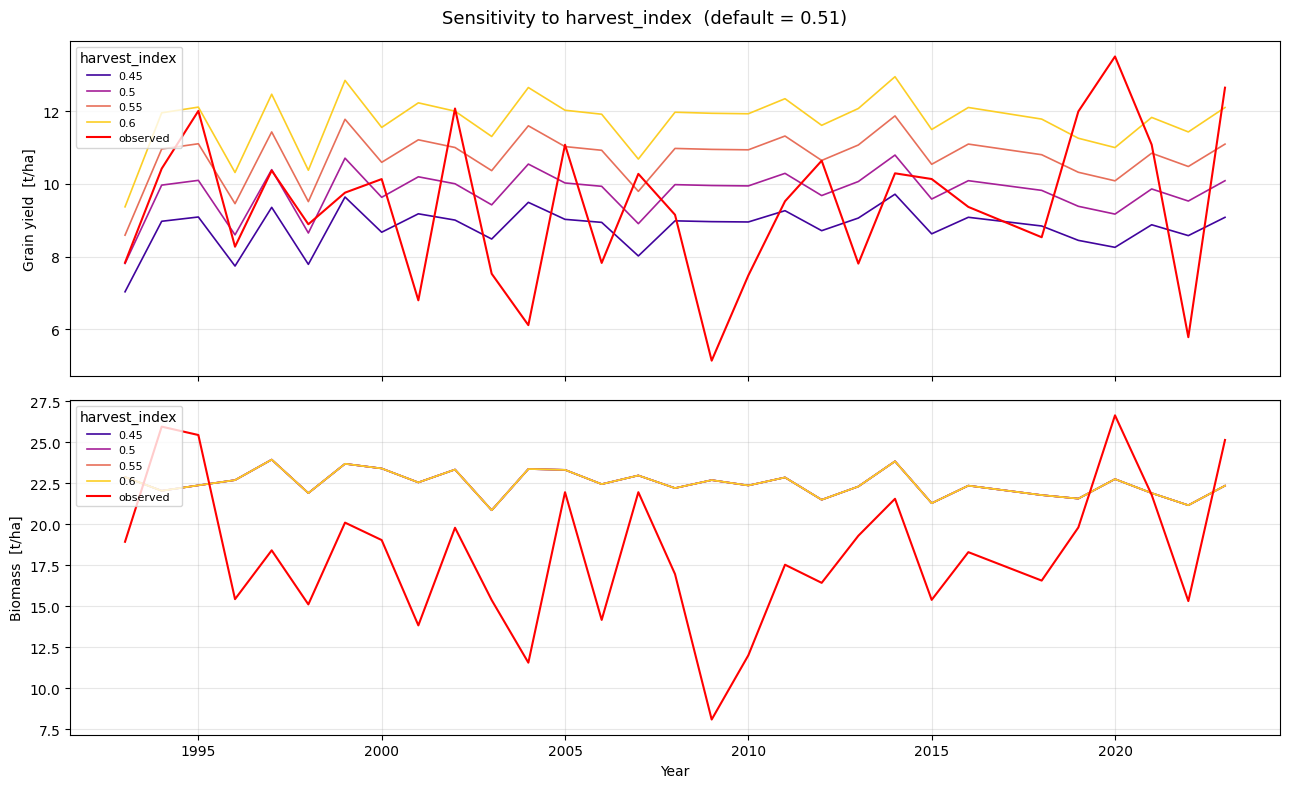

In [7]:
for param_name, results_by_value in sweep_results.items():
    values = sorted(results_by_value.keys())
    default_val = jablje_maize_params[param_name]
    colors = cm.plasma(np.linspace(0.1, 0.9, len(values)))

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    fig.suptitle(f"Sensitivity to {param_name}  (default = {default_val})", fontsize=13)

    for ax, col, obs, label in [
        (axes[0], "Y(dry)",  observed_grain,   "Grain yield  [t/ha]"),
        (axes[1], "BioMass", observed_biomass,  "Biomass  [t/ha]"),
    ]:
        for val, color in zip(values, colors):
            seasonal = results_by_value[val]
            years = seasonal["Year1"].values
            y = seasonal[col].values
            lw = 2.5 if val == default_val else 1.2
            ls = "--" if val == default_val else "-"
            ax.plot(years, y, color=color, linewidth=lw, linestyle=ls,
                    label=f"{val:.3g}" + (" (default)" if val == default_val else ""))

        ax.plot(obs["year"], obs["yield"], color="red", zorder=5,
                   label="observed", clip_on=False)
        ax.set_ylabel(label)
        ax.legend(title=param_name, fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

    axes[1].set_xlabel("Year")
    plt.tight_layout()
    plt.show()

## Daily outputs for a single year

Re-run the parameter sweep with daily output for one representative year to see how each parameter shapes the season trajectory (canopy cover, biomass accumulation, transpiration, yield).

In [8]:
PLOT_YEAR = 2010  # representative mid-range GDD year

single_year_period = [
    {
        "start_date": date(PLOT_YEAR, 1, 1),
        "end_date": date(PLOT_YEAR, 10, 10),
        "planting_date": date(PLOT_YEAR, 5, 3),
        "is_seeding_year": True,
    }
]


def run_daily_with_param(param_name, value):
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        params[param_name] = int(round(value)) if param_name in INTEGER_PARAMS else float(value)
        crop = Crop(name=f"{LOCATION} maize", description=f"{param_name}={value}", params=params)
        simulation = AquaCrop(
            simulation_periods=single_year_period,
            crop=crop,
            soil=soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=True,
            need_seasonal_output=False,
            need_harvest_output=False,
            need_evaluation_output=False,
        )
        with contextlib.redirect_stdout(io.StringIO()):
            results = simulation.run()
        daily = results["day"]
        return param_name, value, daily[daily["DAP"] >= 0].copy()
    finally:
        dir_queue.put(working_dir)


daily_sweep = {name: {} for name in sweep_params}

tasks = [(name, val) for name, values in sweep_params.items() for val in values]
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(run_daily_with_param, name, val) for name, val in tasks]
    for future in as_completed(futures):
        param_name, value, daily = future.result()
        daily_sweep[param_name][value] = daily

print("Done.")

Results successfully parsed


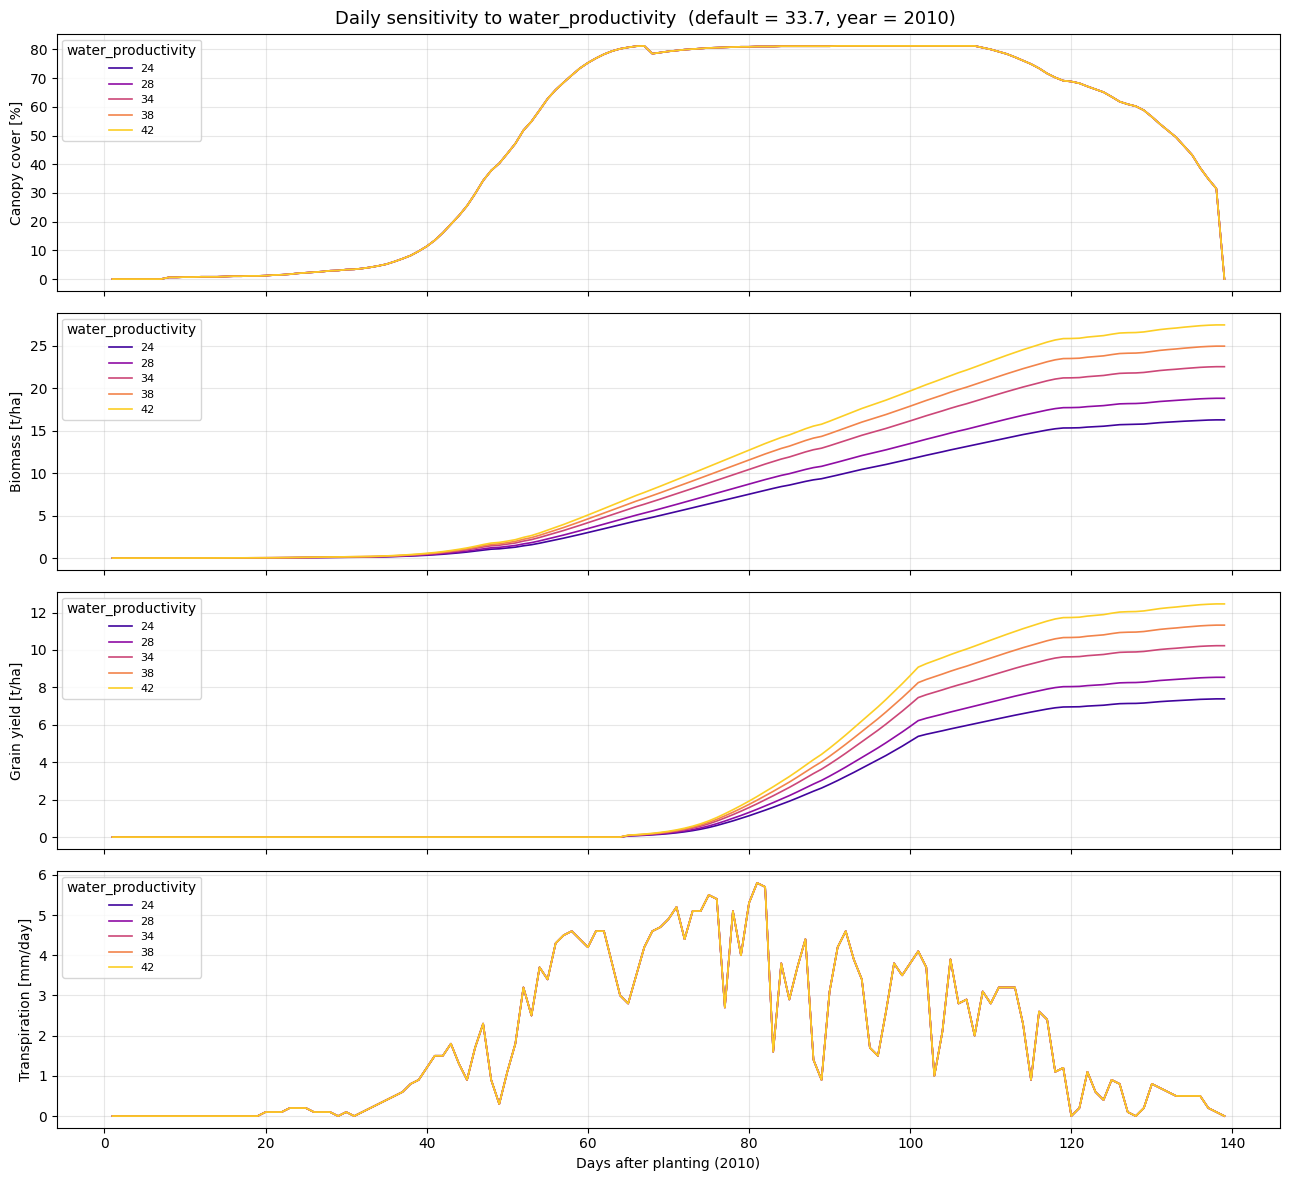

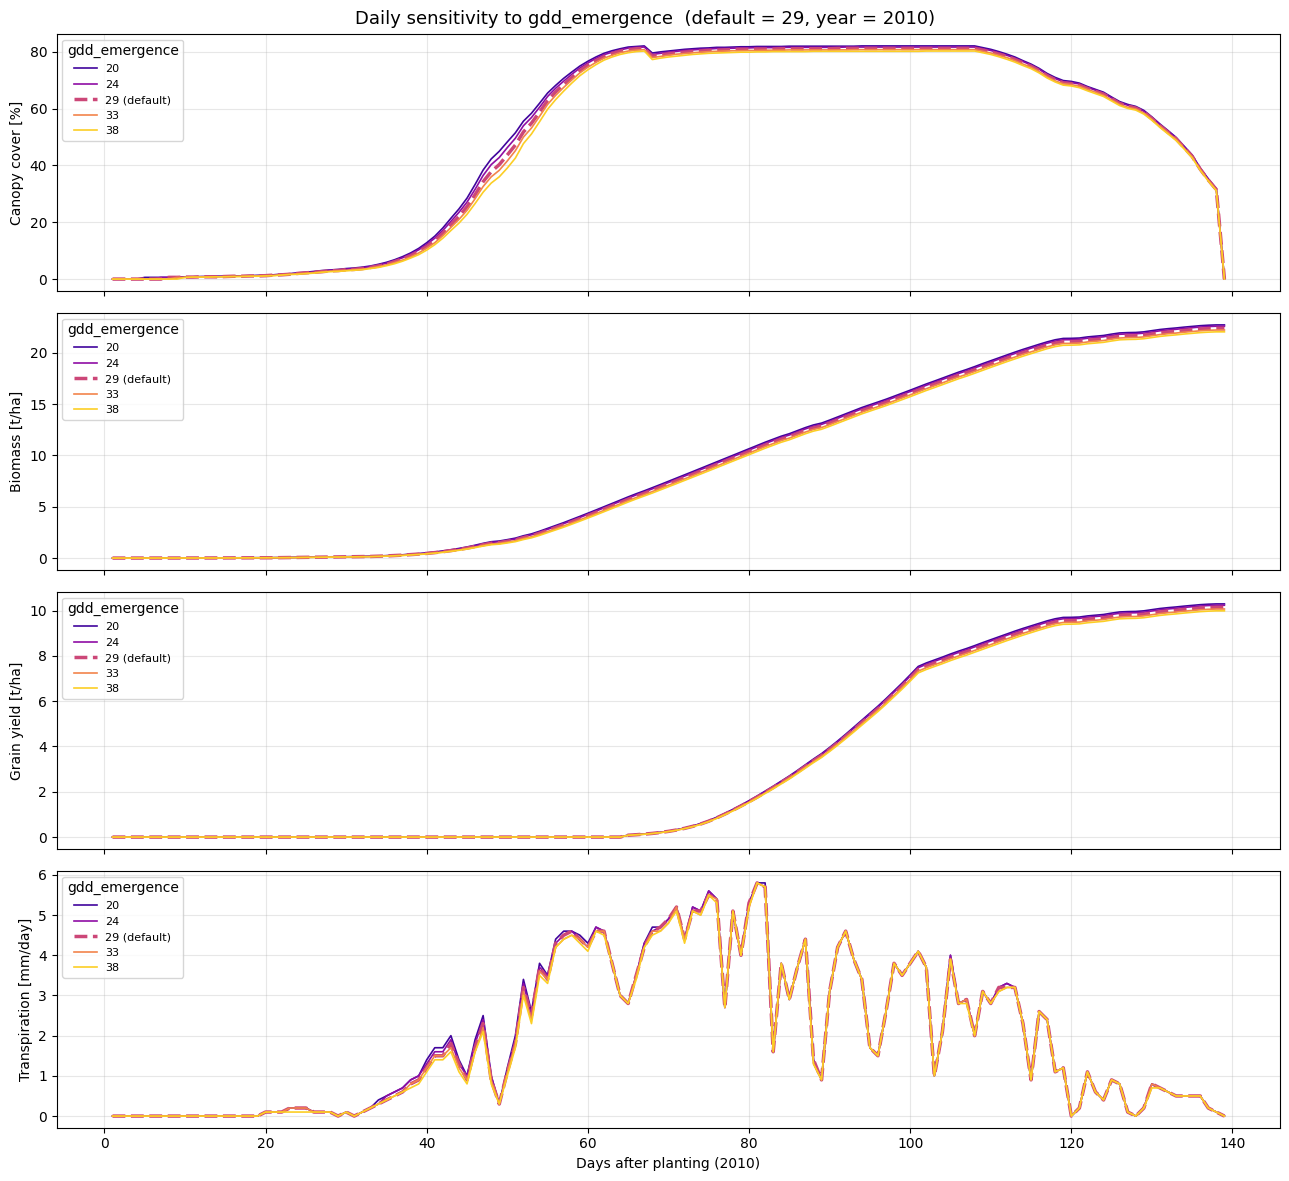

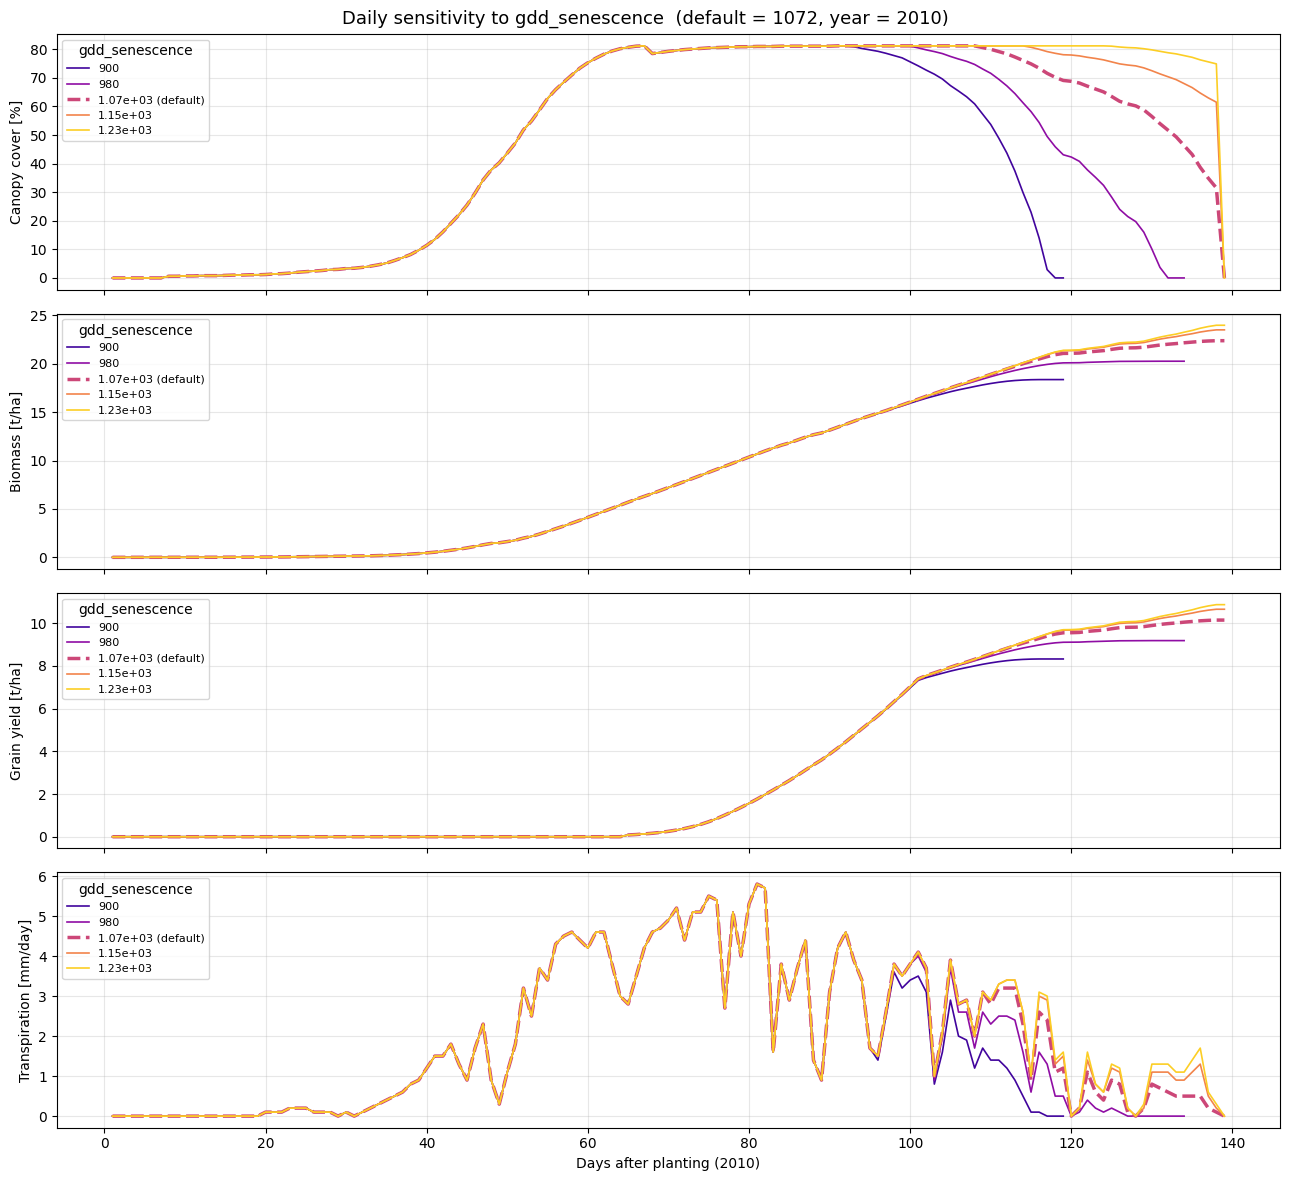

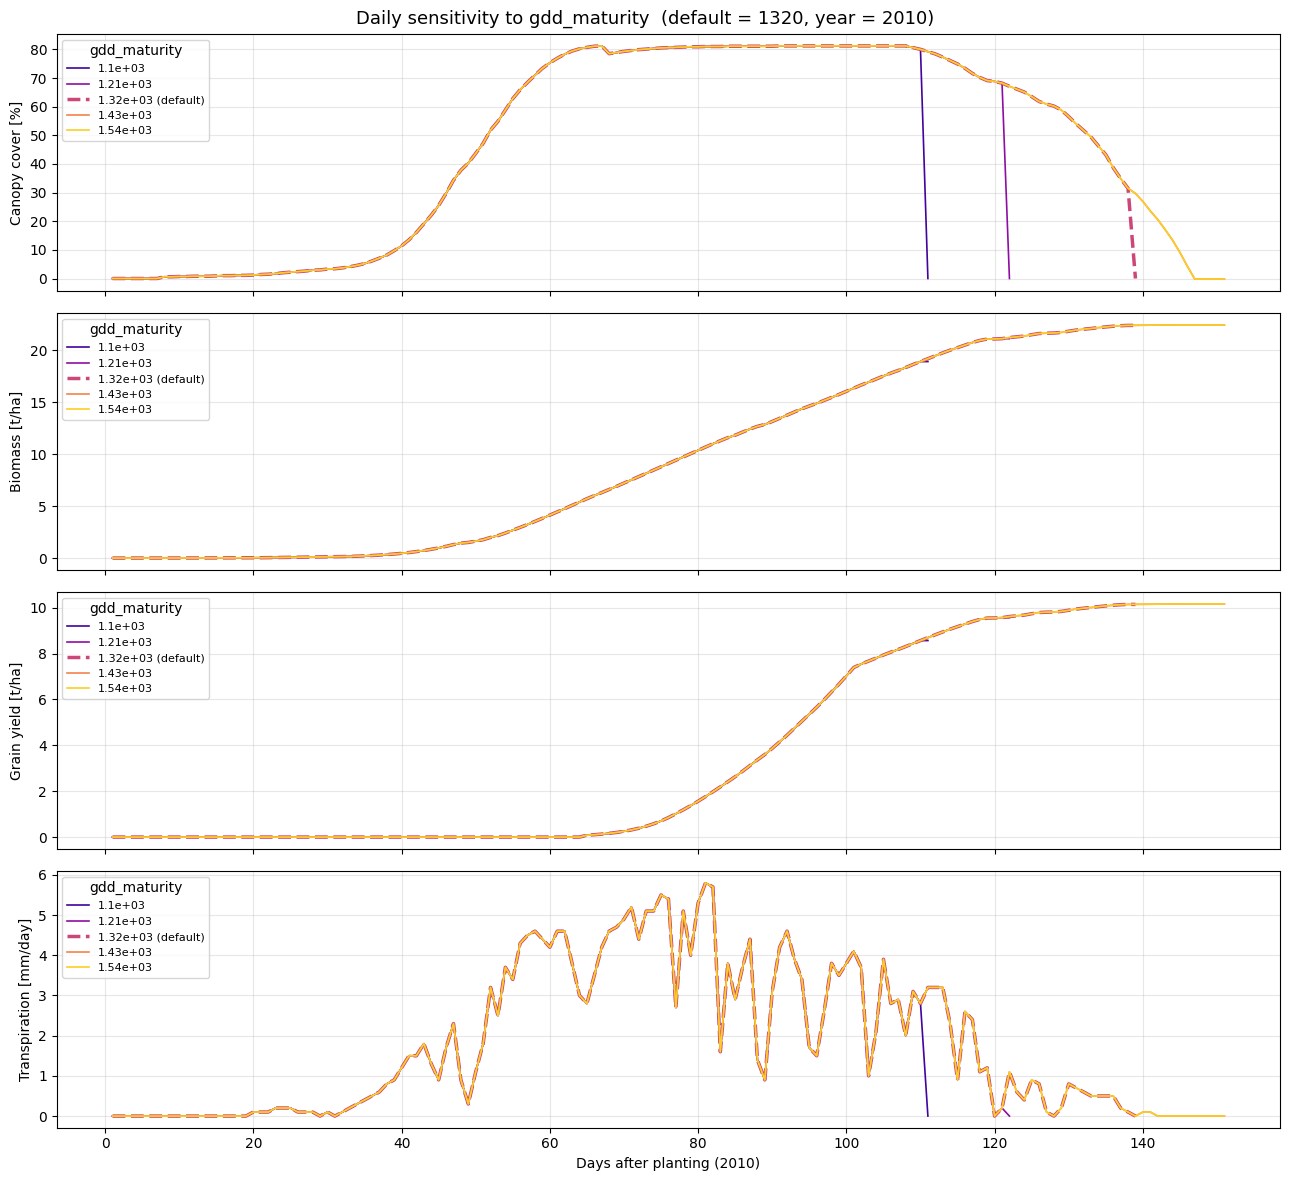

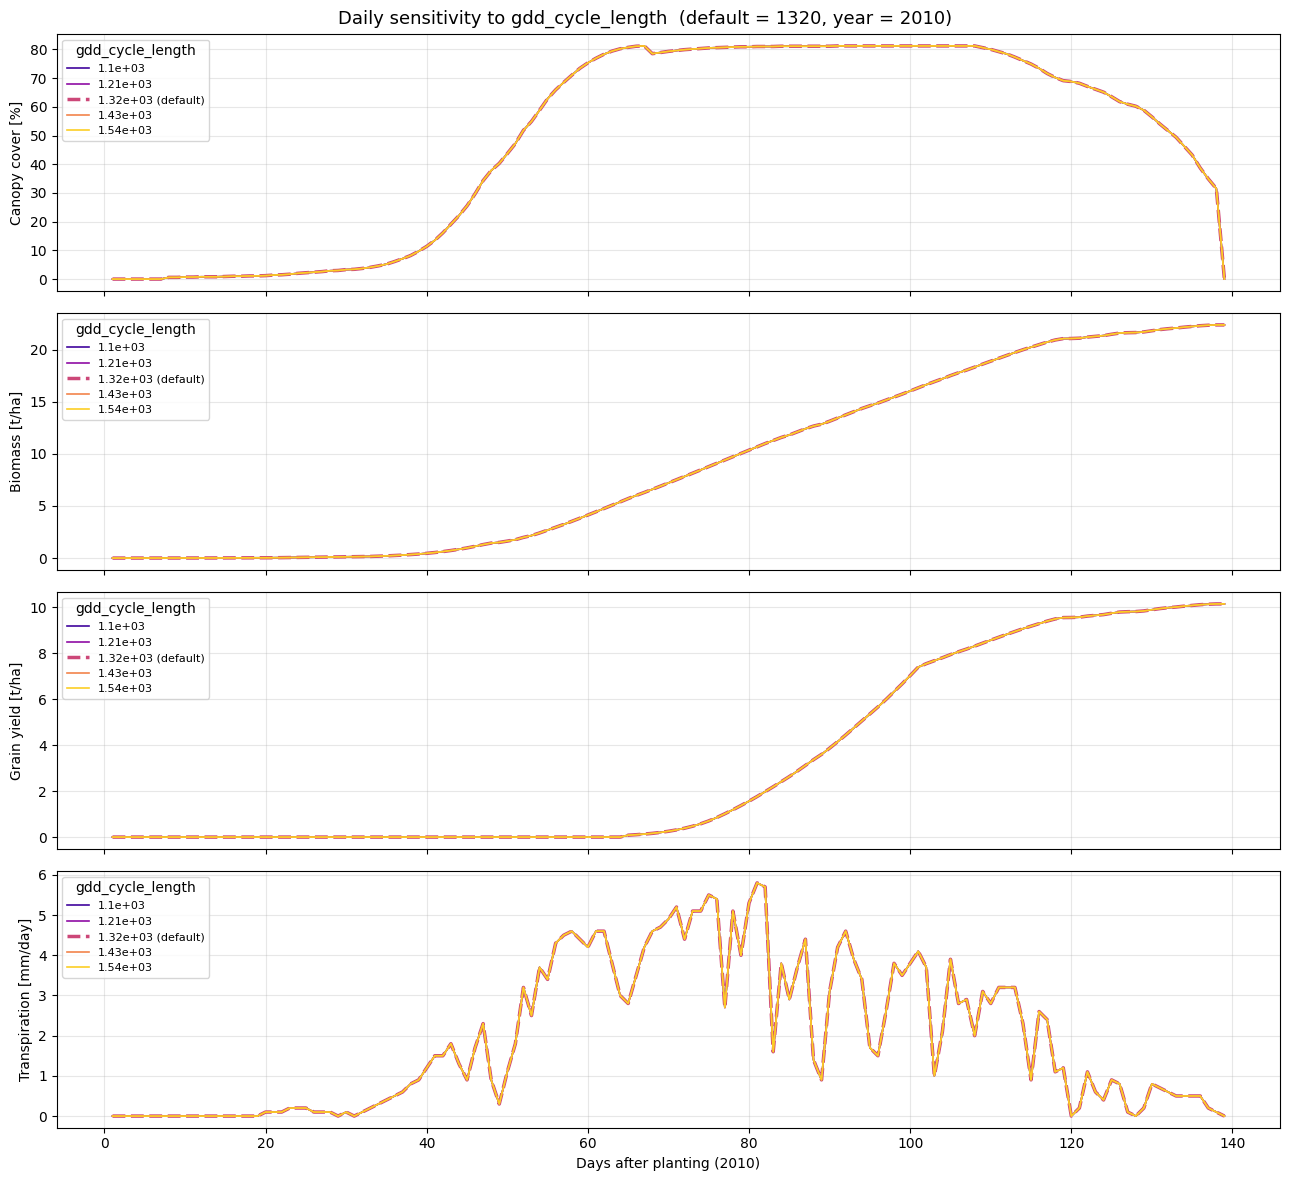

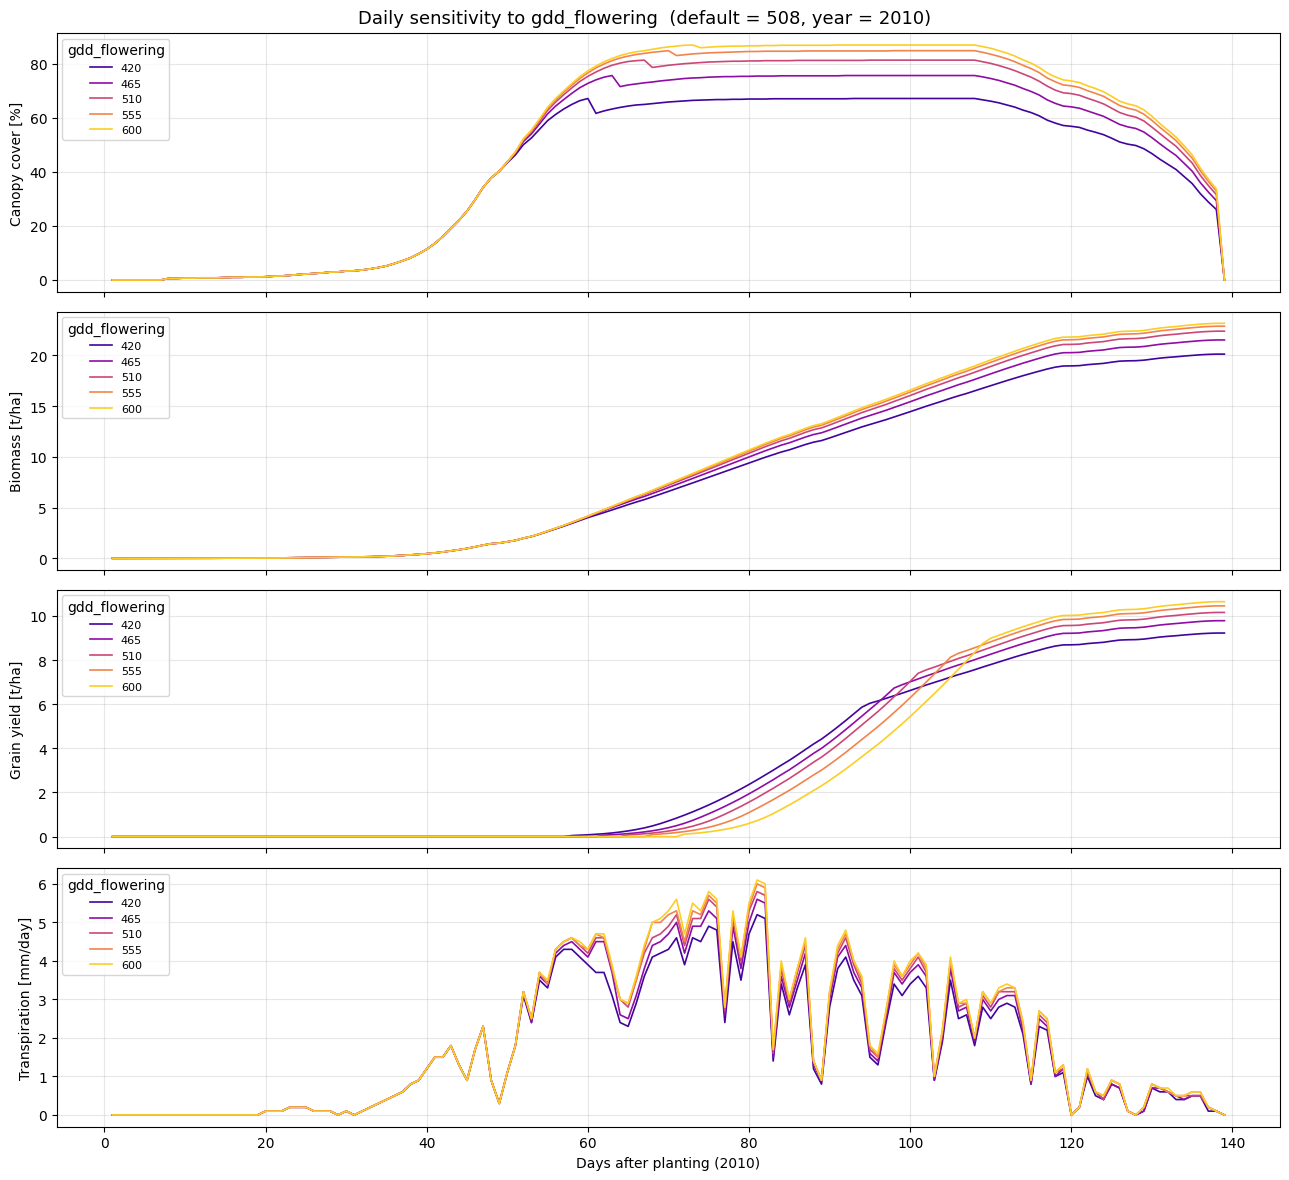

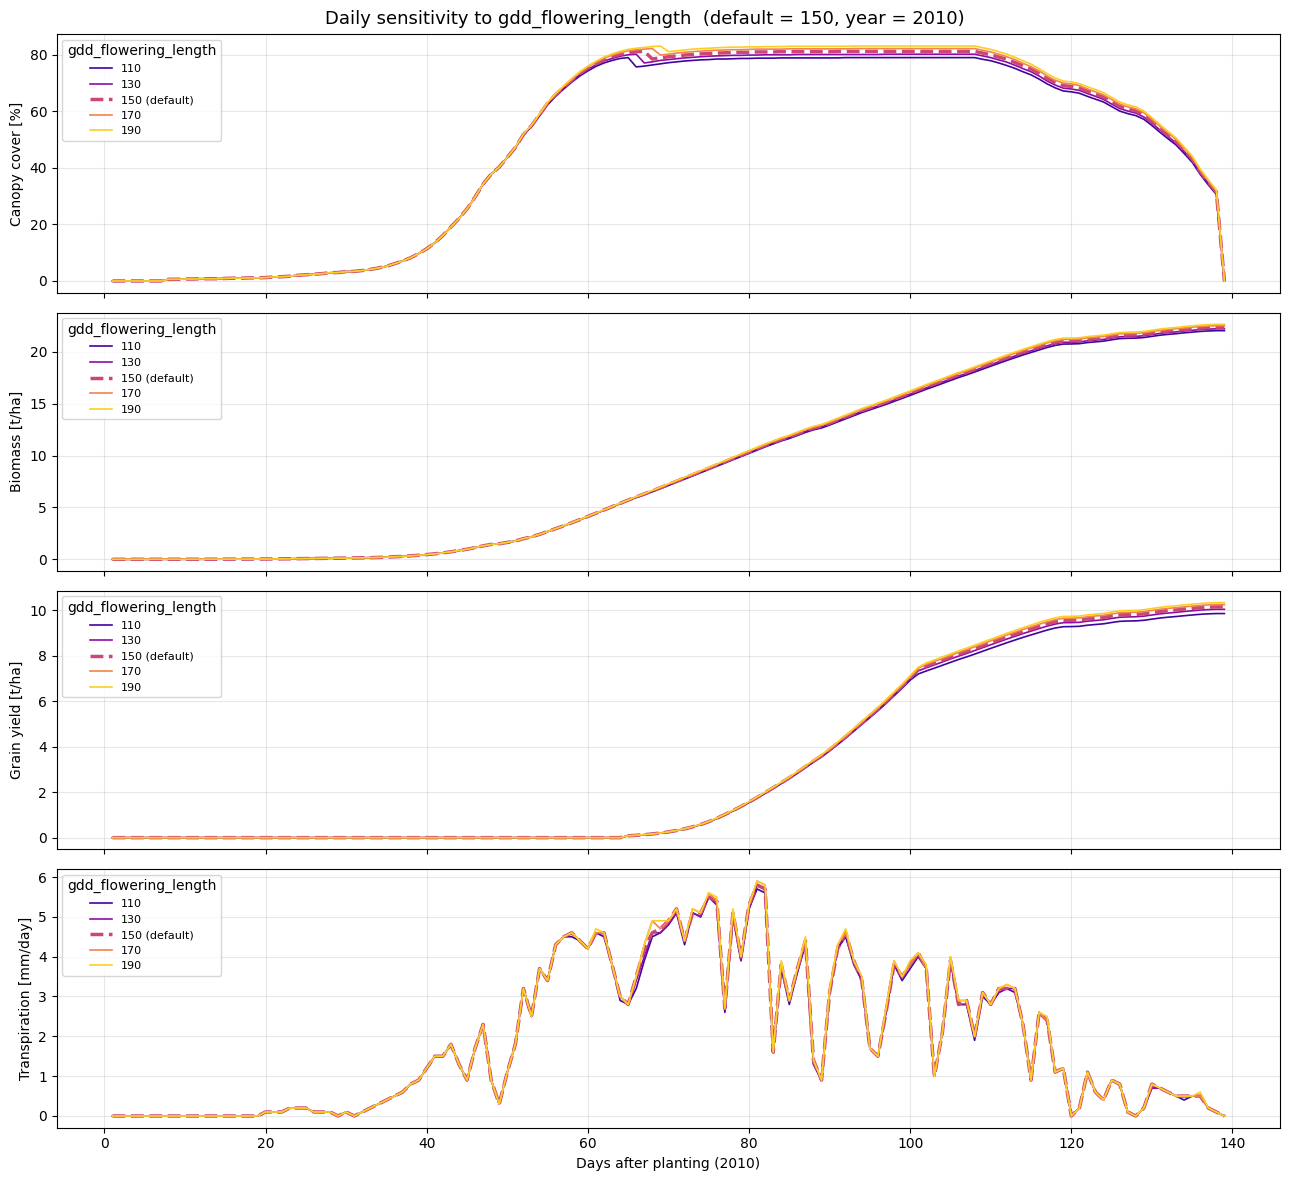

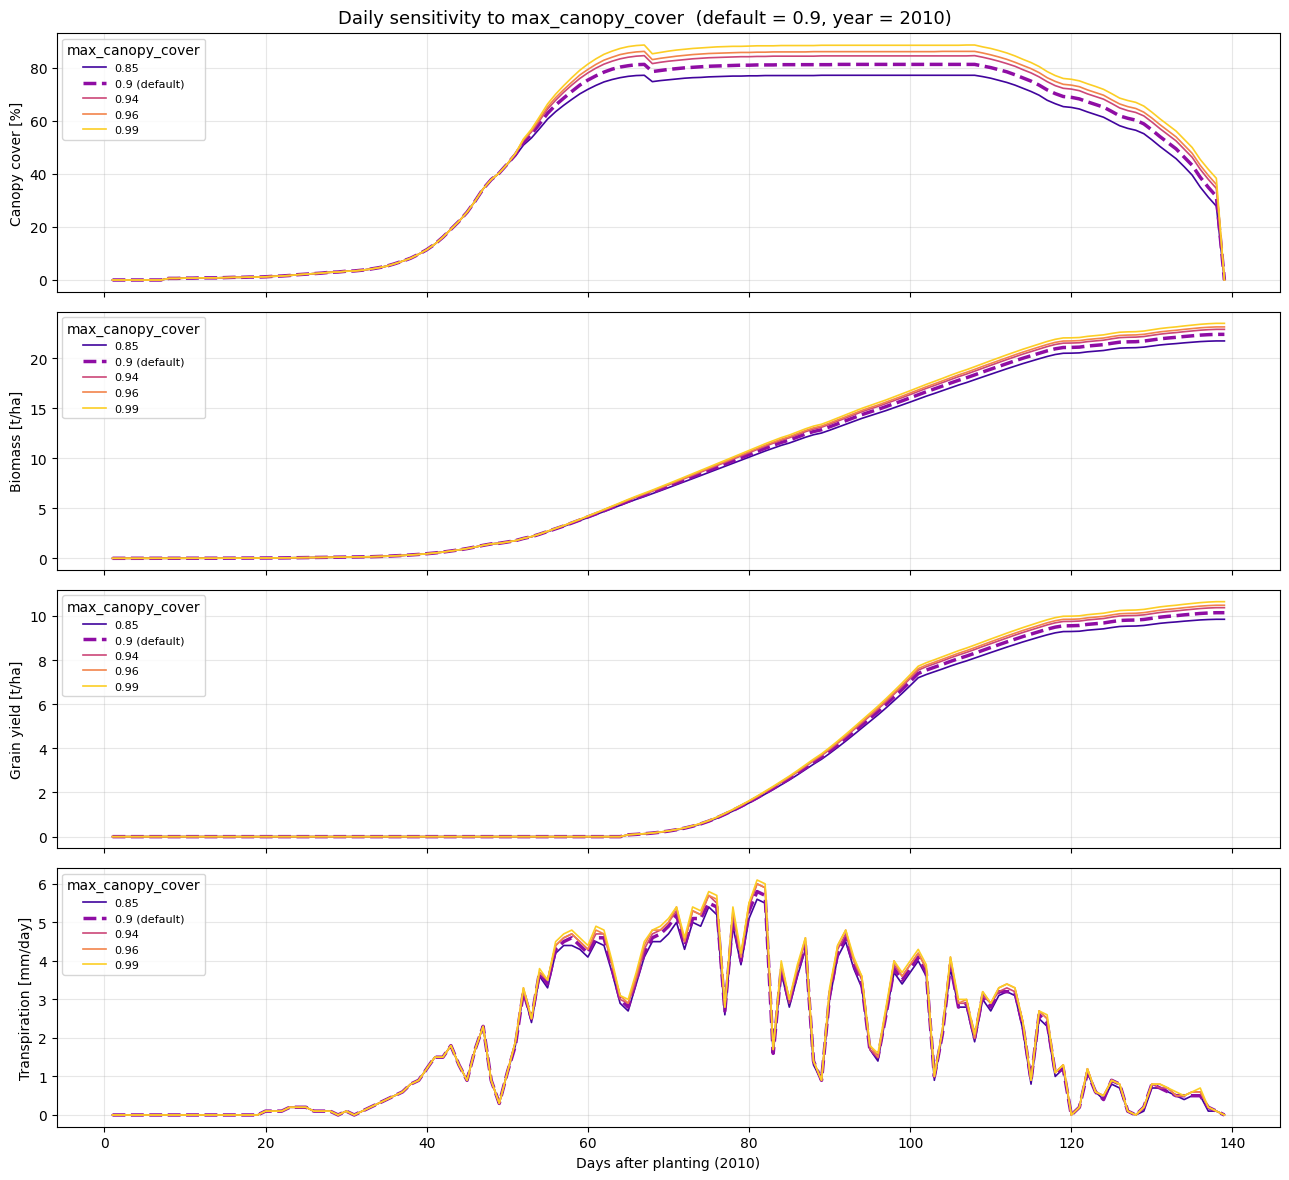

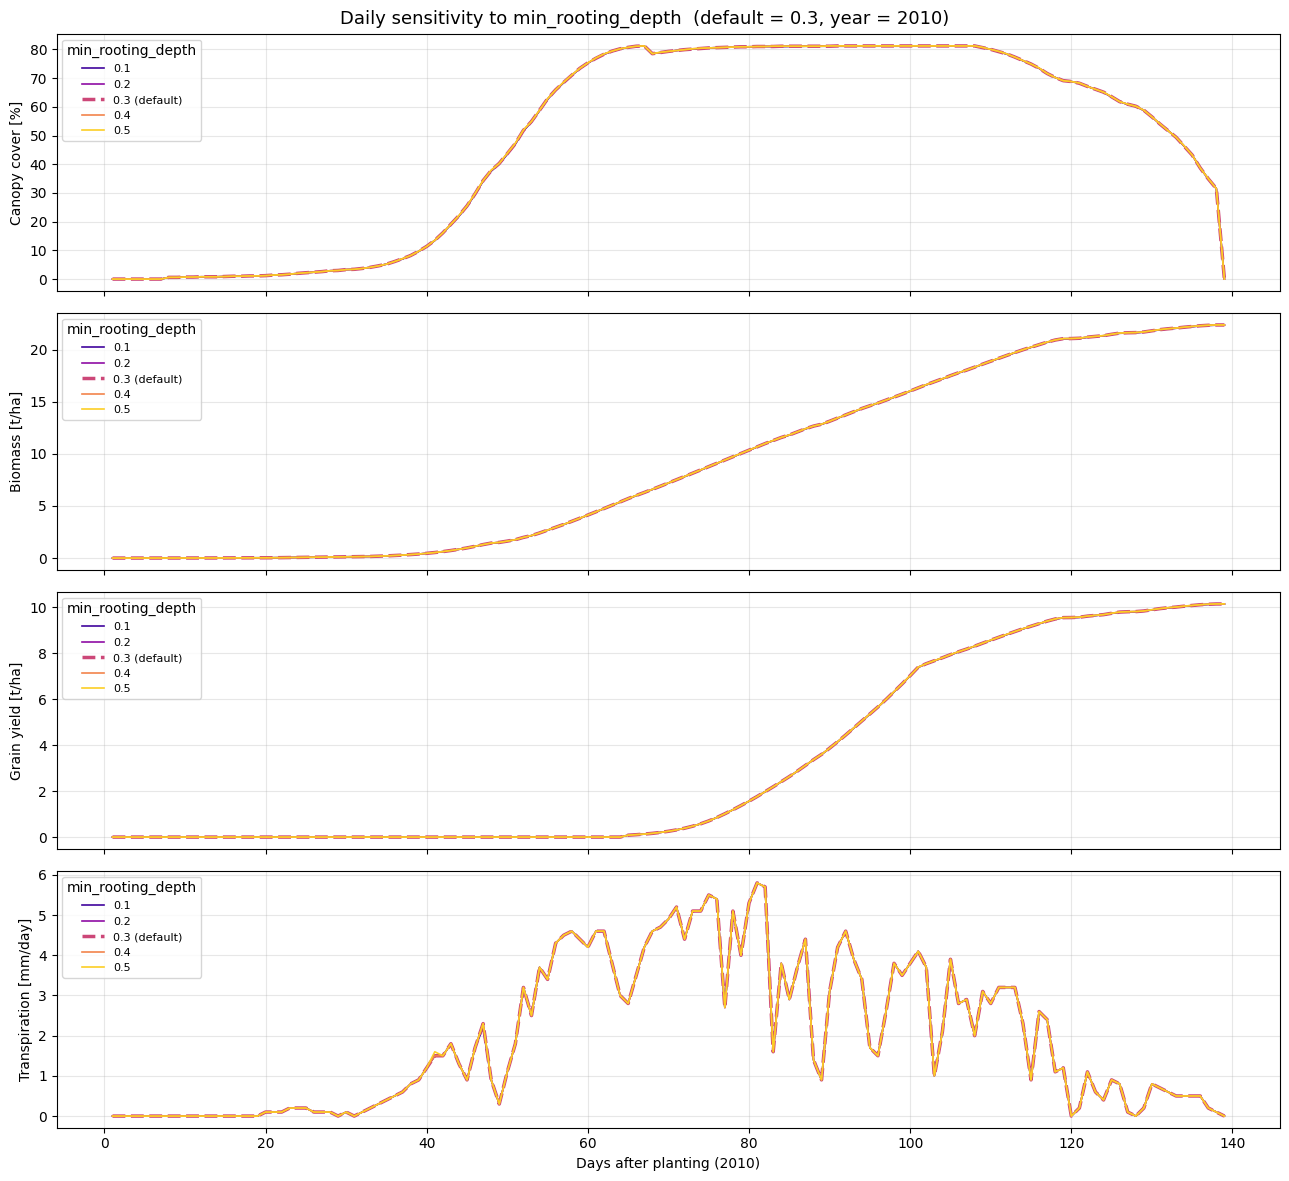

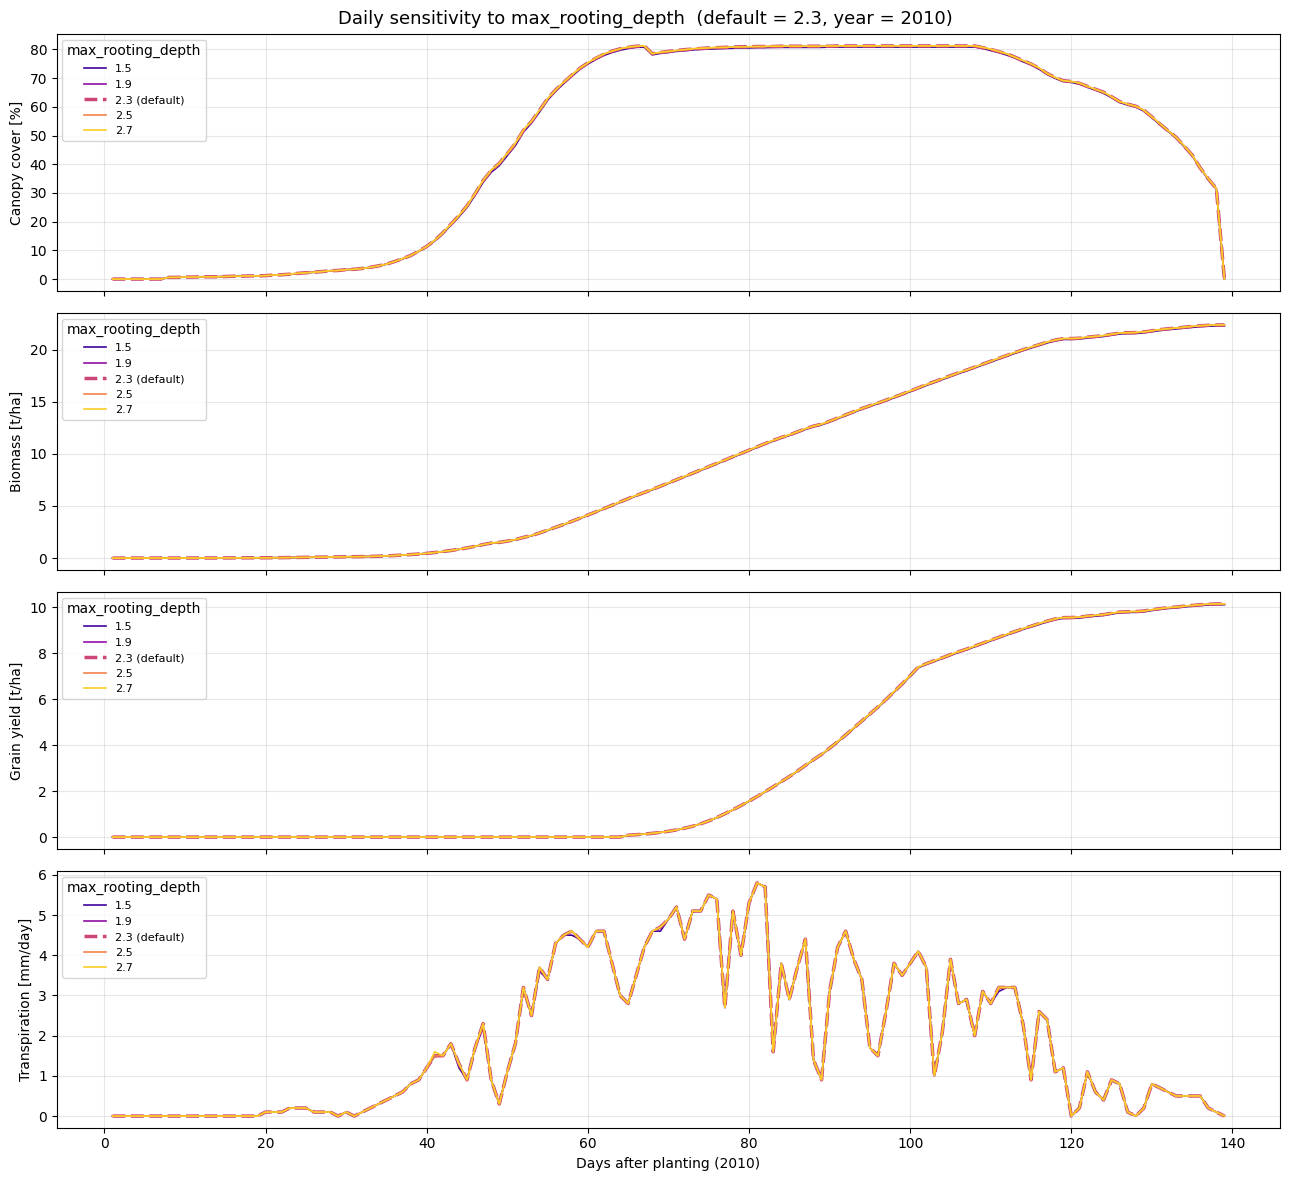

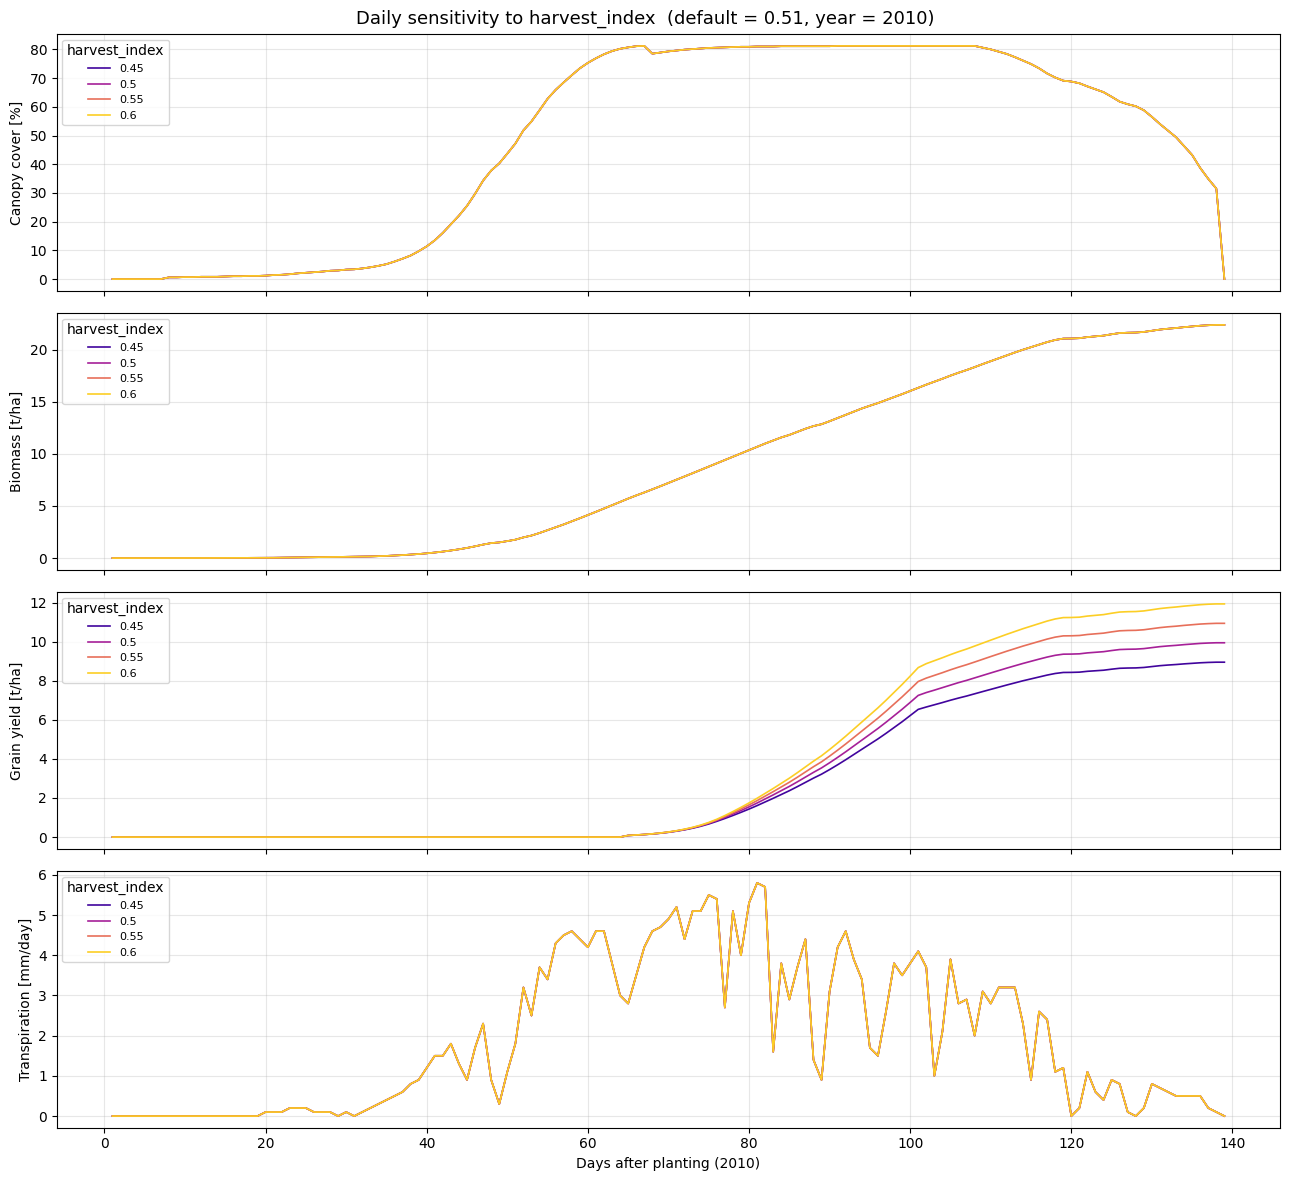

In [9]:
daily_outputs = [
    ("CC",      "Canopy cover [%]"),
    ("Biomass", "Biomass [t/ha]"),
    ("Y(dry)",  "Grain yield [t/ha]"),
    ("Tr",      "Transpiration [mm/day]"),
]

for param_name, results_by_value in daily_sweep.items():
    values = sorted(results_by_value.keys())
    default_val = jablje_maize_params[param_name]
    colors = cm.plasma(np.linspace(0.1, 0.9, len(values)))

    fig, axes = plt.subplots(len(daily_outputs), 1, figsize=(13, 3 * len(daily_outputs)), sharex=True)
    fig.suptitle(
        f"Daily sensitivity to {param_name}  (default = {default_val}, year = {PLOT_YEAR})",
        fontsize=13,
    )

    for ax, (col, ylabel) in zip(axes, daily_outputs):
        for val, color in zip(values, colors):
            daily = results_by_value[val]
            lw = 2.5 if val == default_val else 1.2
            ls = "--" if val == default_val else "-"
            ax.plot(
                daily["DAP"].values,
                daily[col].values,
                color=color,
                linewidth=lw,
                linestyle=ls,
                label=f"{val:.3g}" + (" (default)" if val == default_val else ""),
            )
        ax.set_ylabel(ylabel)
        ax.legend(title=param_name, fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel(f"Days after planting ({PLOT_YEAR})")
    plt.tight_layout()
    plt.show()